This notebook implements a Denoising Autoencoder using TensorFlow and Keras to remove random noise from the MNIST dataset.

### 1. Import Libraries

We begin by importing the necessary libraries for building the neural network, handling data, and visualizing results.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

### 2. Load and Preprocess Data

The MNIST dataset consists of 28x28 grayscale images of handwritten digits. We normalize these pixel values to a range of [0, 1] and reshape them to include a channel dimension, which is required for Convolutional Neural Network (CNN) layers.

In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the images to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape the data to include the channel dimension
x_train = np.reshape(x_train, (x_train.shape[0], 28, 28, 1))
x_test = np.reshape(x_test, (x_test.shape[0], 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 3. Add Noise to the Images

To train a denoising autoencoder, we must provide it with "corrupted" versions of the images. We add random Gaussian noise to the training and testing sets.

In [3]:
# Function to add random noise
def add_noise(images, noise_factor=0.5):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)  # Keep values between 0 and 1
    return noisy_images

# Add noise to training and test images
x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

### 4. Build the Denoising Autoencoder Architecture

The architecture consists of two main parts:

* **Encoder:** Uses convolutional and max-pooling layers to compress the noisy image into a lower-dimensional latent representation.
* **Decoder:** Uses convolutional and upsampling layers to reconstruct the original clean image from the compressed data.

In [4]:
# Define the encoder
input_img = layers.Input(shape=(28, 28, 1))

# Convolutional layers for encoding
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Define the decoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Define and compile the model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### 5. Discussion: Training Strategy

Unlike standard classification models that map images to labels, the autoencoder maps **noisy images** to **clean images**. By using `binary_crossentropy` as the loss function, the model penalizes pixel-wise differences between the reconstruction and the original ground truth.

In [5]:
# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 180s 380ms/step - loss: 0.1525 - val_loss: 0.1129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 388ms/step - loss: 0.1102 - val_loss: 0.1062
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 343ms/step - loss: 0.1052 - val_loss: 0.1026
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 338ms/step - loss: 0.1024 - val_loss: 0.1010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 340ms/step - loss: 0.1005 - val_loss: 0.0989
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 340ms/step - loss: 0.0991 - val_loss: 0.0978
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 338ms/step - loss: 0.0981 - val_loss: 0.0973
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 207s 348ms/step - loss: 0.0974 - val_loss: 0.0962
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 344ms/step - loss: 0.0967 - val_loss: 0.0967
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 336ms/step - loss: 0.0961 - val_loss: 0.0956


### 6. Visualize Results and Reconstructions

Finally, we pass the noisy test images through the trained model to see how effectively it can recover the original digits.

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


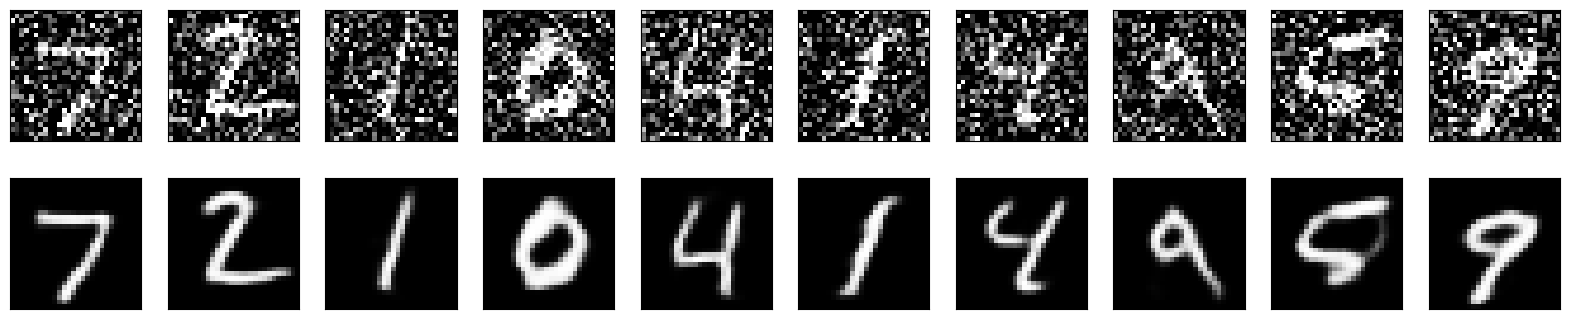

In [6]:
# Reconstruct noisy images
decoded_imgs = autoencoder.predict(x_test_noisy)

# Plot some of the noisy and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### 7. Discussion: Performance Analysis

A successful denoising autoencoder should produce images that are significantly clearer than the noisy inputs. If the reconstructed images appear blurry, it suggests the latent space might be too small or the model needs more training epochs. Conversely, if noise remains, the model may not have learned the underlying patterns of the digits effectively enough to distinguish them from random variance.

# Task 1: Deep Autoencoder
The Deep Autoencoder extends the basic architecture by adding more hidden layers. This allows the model to learn more complex, hierarchical representations of the data.

In [7]:
# --- Deep Autoencoder Implementation ---

# Define the architecture
input_deep = layers.Input(shape=(28, 28, 1))

# Deep Encoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_deep)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded_deep = layers.MaxPooling2D((2, 2), padding='same')(x)

# Deep Decoder
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded_deep)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x) # Remove padding to reach 28x28
x = layers.UpSampling2D((2, 2))(x)
decoded_deep = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Model Setup
deep_autoencoder = models.Model(input_deep, decoded_deep)
deep_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Discussion: Hierarchical Learning
# By adding more layers, the network can extract more abstract features.
# The first layers might detect edges, while deeper layers detect shapes
# specific to digits. This often leads to sharper reconstructions.

deep_autoencoder.fit(x_train, x_train, # Training on clean images for standard AE
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 220s 463ms/step - loss: 0.1571 - val_loss: 0.1107
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 260s 459ms/step - loss: 0.1037 - val_loss: 0.0968
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 256s 447ms/step - loss: 0.0949 - val_loss: 0.0912
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 213s 455ms/step - loss: 0.0902 - val_loss: 0.0870
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 212s 452ms/step - loss: 0.0873 - val_loss: 0.0849
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 213s 454ms/step - loss: 0.0851 - val_loss: 0.0832
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 264s 459ms/step - loss: 0.0836 - val_loss: 0.0817
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 260s 454ms/step - loss: 0.0823 - val_loss: 0.0807
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 266s 463ms/step - loss: 0.0811 - val_loss: 0.0804
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 263s 464ms/step - loss: 0.0802 - val_loss: 0.0792


## Discussion: Complexity and Feature Extraction
The Deep Autoencoder differs from the basic version by incorporating multiple hidden layers. In a convolutional context, these additional layers allow the network to learn a hierarchical feature representation.

The initial layers typically capture simple features like edges and gradients.

The deeper layers combine these to understand more complex structures, such as the curves of a "2" or the loops of an "8".

Because it is trained on clean data in this task, its primary goal is efficient dimensionality reduction—learning to squeeze an image into a very small latent representation and then reconstruct it with minimal loss of detail.

## Visualization Code
This code compares the original clean images with the reconstructions produced by the deep model.

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


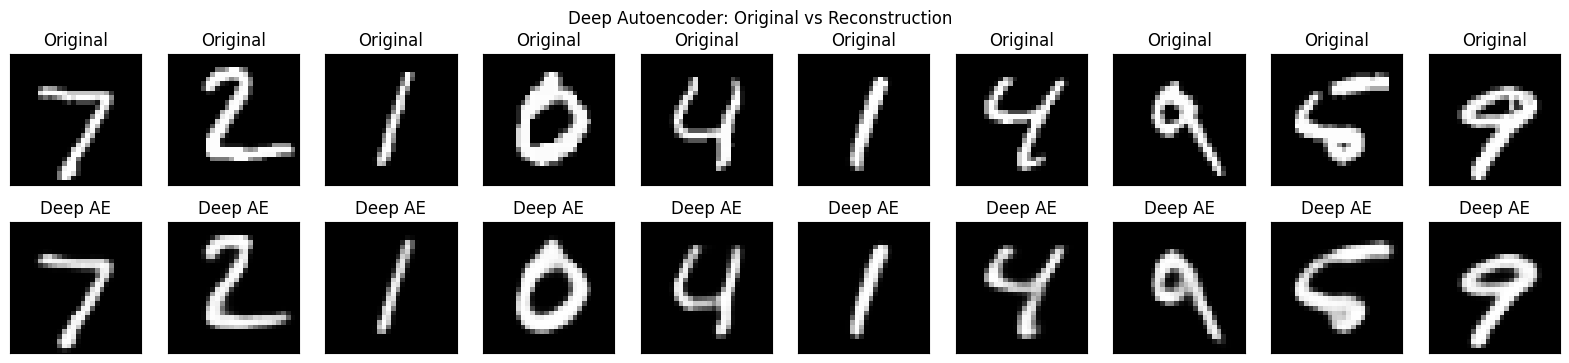

In [8]:
# Reconstruct images using the Deep Autoencoder
decoded_deep_imgs = deep_autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display deep reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_deep_imgs[i].reshape(28, 28), cmap="gray")
    ax.set_title("Deep AE")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Deep Autoencoder: Original vs Reconstruction")
plt.show()

# Task 2: Variational Autoencoder (VAE)
A Variational Autoencoder (VAE) is a generative model. Instead of mapping an input to a fixed point in the latent space, it maps it to a probability distribution (mean and variance). This allows us to sample new data from the latent space.

In [2]:
# Load and preprocess data (Run this first)
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to include channel dimension (28, 28, 1)
x_train = np.reshape(x_train, (x_train.shape[0], 28, 28, 1))
x_test = np.reshape(x_test, (x_test.shape[0], 28, 28, 1))

print("Data loaded successfully. x_train shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded successfully. x_train shape: (60000, 28, 28, 1)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 208ms/step - kl_loss: 2.9579 - loss: 191.0852 - reconstruction_loss: 188.1274
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - kl_loss: 5.1873 - loss: 175.3906 - reconstruction_loss: 170.2032
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - kl_loss: 5.7651 - loss: 162.2574 - reconstruction_loss: 156.4923
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - kl_loss: 5.7879 - loss: 157.4019 - reconstruction_loss: 151.6140
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 193ms/step - kl_loss: 6.3493 - loss: 157.1062 - reconstruction_loss: 150.7569
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 191ms/step - kl_loss: 6.2754 - loss: 153.2060 - reconstruction_loss: 146.9306
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 198ms/step - kl_loss: 6.2729 - loss: 162.5756 - reconstruction_loss: 156.3027
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 190ms/step - kl_loss: 6.1889 - loss: 157.2751 - reconstruction_loss: 151.0862
Epoch 9/15
469/469 ━

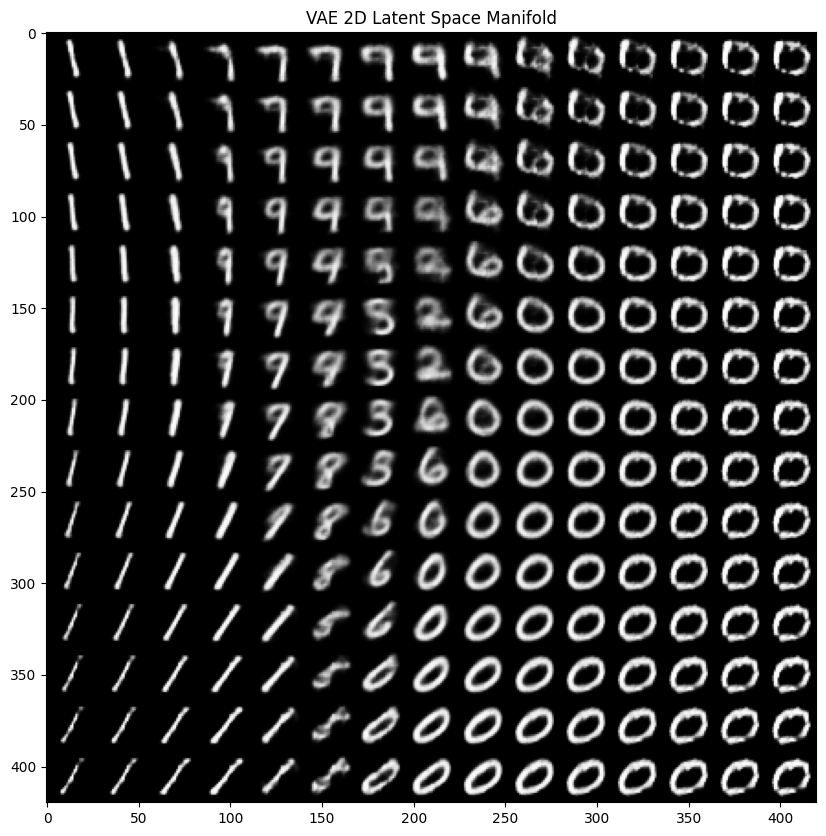

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Sampling Layer
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. Build the Encoder
latent_dim = 2
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 3. Build the Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = models.Model(latent_inputs, vae_outputs, name="decoder")

# 4. Define VAE Model with Custom Training Logic
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# 5. Compile and Train
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(x_train, epochs=15, batch_size=128)

# 6. Discussion: Structural Differences
# Unlike standard autoencoders, the VAE introduces a "Sampling" layer.
# This forces the model to learn a continuous latent space distribution
# rather than discrete points. This is why the loss function includes
# KL Divergence—to ensure the latent variables z_mean and z_log_var
# stay close to a standard normal distribution.

# 7. Visualization of the 2D Latent Space Manifold
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = vae_decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.title("VAE 2D Latent Space Manifold")
plt.show()

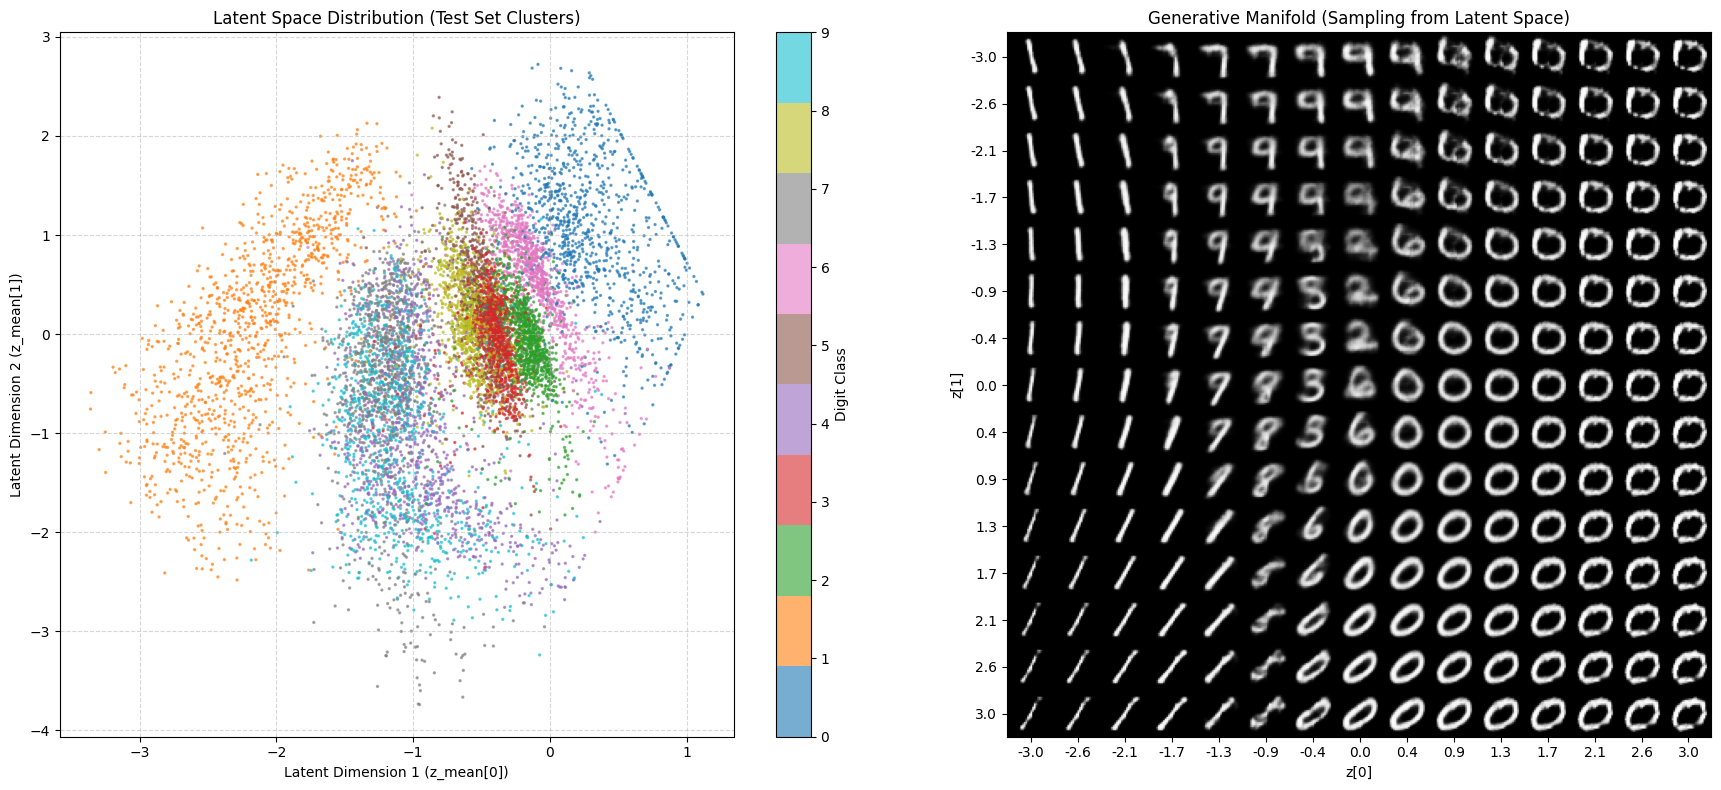

In [4]:
# --- Detailed Visualization for Task 2 (VAE) ---
import matplotlib.pyplot as plt
import numpy as np

def plot_vae_results(encoder, decoder, x_test, y_test, batch_size=128):
    """
    Plots the latent space distribution and the manifold of generated digits.
    """
    # 1. Plot Latent Space Clusters
    # We use the encoder to map the test set to the latent space
    z_mean, _, _ = encoder.predict(x_test, batch_size=batch_size, verbose=0)

    plt.figure(figsize=(18, 8))

    # Subplot 1: Scatter plot of the latent space
    plt.subplot(1, 2, 1)
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap='tab10', alpha=0.6, s=2)
    plt.colorbar(label='Digit Class')
    plt.xlabel("Latent Dimension 1 (z_mean[0])")
    plt.ylabel("Latent Dimension 2 (z_mean[1])")
    plt.title("Latent Space Distribution (Test Set Clusters)")
    plt.grid(True, linestyle='--', alpha=0.5)

    # 2. Plot Manifold (Generated Digits)
    n = 15  # 15x15 grid
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    # Linearly spaced coordinates corresponding to the 2D latent space
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    # Subplot 2: The Generated Manifold
    plt.subplot(1, 2, 2)
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)

    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap='Greys_r')
    plt.title("Generative Manifold (Sampling from Latent Space)")

    plt.tight_layout()
    plt.show()

# To run this, ensure you have loaded y_test labels from the dataset
(_, _), (_, y_test) = mnist.load_data()

# Execute the visualization
plot_vae_results(vae_encoder, vae_decoder, x_test, y_test)

# The Cluster Map (Left)
This plot shows how the encoder has learned to separate different digits without ever being told what the digits are (unsupervised). You will notice that:

Similar Shapes Cluster Together: For example, '1's often form a tight, distinct line, while '4's, '7's, and '9's might be found closer to each other because they share similar strokes.

The Circular Constraint: Because of the KL-Divergence term, you will see the majority of the points are centered around (0,0) in a somewhat circular or "Gaussian" blob.

# The Generative Manifold (Right)
This grid is the "creative" part of the VAE.

Continuous Transitions: Unlike a standard autoencoder, there are no "dead zones." If you move from a region that generates a '0' to a region that generates a '6', you will see the loop of the '0' slowly morphing into the tail of the '6'.

Interpolation: Every coordinate in this space corresponds to a valid, visually plausible digit because the model was forced to map the data to a continuous probability distribution.

## Discussion: Generative Modeling and Latent Space
The Variational Autoencoder (VAE) introduces a probabilistic twist to the architecture. Instead of encoding an input into a single fixed point, it encodes it as a distribution (defined by a mean and variance).

The KL Divergence: This loss term acts as a regularizer, forcing the latent space to be continuous and centered around zero.

Generative Capability: Unlike standard autoencoders, we can "sample" a random point from this latent distribution and pass it through the decoder to create a brand-new digit that never existed in the training set.
